In [1]:
## importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
df = pd.read_csv("Total_Dataset.csv")
df.head()

,device,hive number,date,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,wind speed,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
0,1,5,6/8/2022 14:52,36.42,30.29,1007.45,26.68,52,1013,8.75,...,23.118408,3.729802,13.262281,7.297372,7.976750,0.531082,-2.822930,-2.018874,-7.966803,-4.890919
1,1,5,6/8/2022 15:51,33.56,33.98,1006.93,25.99,53,1012,10.29,...,31.598898,3.833501,17.303408,5.778300,8.560819,0.950567,-0.787530,-1.149038,-8.600332,-3.450061
2,1,5,6/8/2022 17:21,29.01,42.73,1006.68,24.49,56,1012,8.75,...,31.906893,-0.825872,19.108456,0.742097,6.884298,-6.125057,-6.144371,-3.714840,-10.949466,-3.352849
3,1,5,6/8/2022 18:20,30.51,36.74,1006.68,22.97,59,1012,8.23,...,31.365660,2.954570,15.744356,2.058204,5.496050,-2.597139,-3.309875,-2.507883,-10.743480,-3.853842
4,1,5,6/8/2022 19:20,30.32,35.55,1006.58,21.52,61,1012,7.20,...,28.491236,3.291468,13.285162,1.844446,4.557807,-3.080177,-2.057316,-1.299290,-10.193349,-3.595244


## Data Cleaning
### Handling Missing values
1. Handling Missing values
2. Handling Duplicates
3. Check data type
4. Understand the dataset

In [3]:
df.isnull().sum()

device                 0
hive number            0
date                   0
hive temp              0
hive humidity          0
hive pressure          0
weather temp           2
weather humidity       0
weather pressure       0
wind speed             2
gust speed           952
weatherID              0
cloud coverage         0
rain                   0
lat                    2
long                   2
Filename               0
queen presence         0
queen acceptance       0
frames                 0
target                 0
time                   0
queen status           0
RMS_Energy             0
Spectral_Centroid      0
Spectral_Contrast      0
MFCC_1                 0
MFCC_2                 0
MFCC_3                 0
MFCC_4                 0
MFCC_5                 0
MFCC_6                 0
MFCC_7                 0
MFCC_8                 0
MFCC_9                 0
MFCC_10                0
MFCC_11                0
MFCC_12                0
MFCC_13                0
dtype: int64

In [4]:
df.dtypes

device                 int64
hive number            int64
date                  object
hive temp            float64
hive humidity        float64
hive pressure        float64
weather temp         float64
weather humidity       int64
weather pressure       int64
wind speed           float64
gust speed           float64
weatherID              int64
cloud coverage         int64
rain                   int64
lat                  float64
long                 float64
Filename              object
queen presence         int64
queen acceptance       int64
frames                 int64
target                 int64
time                 float64
queen status           int64
RMS_Energy           float64
Spectral_Centroid    float64
Spectral_Contrast    float64
MFCC_1               float64
MFCC_2               float64
MFCC_3               float64
MFCC_4               float64
MFCC_5               float64
MFCC_6               float64
MFCC_7               float64
MFCC_8               float64
MFCC_9        

In [5]:
df['queen status'].value_counts()

queen status
3    630
2    259
0    175
1    158
Name: count, dtype: int64

In [6]:
columns_to_drop = ['device', 'hive number', 'date', 'Filename', 'lat', 'long',  
                   'wind speed', 'gust speed', 'weatherID', 'cloud coverage', 'rain']

df = df.drop(columns=columns_to_drop)


In [7]:
df.head()

,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,queen presence,queen acceptance,frames,target,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
0,36.42,30.29,1007.45,26.68,52,1013,1,2,8,0,...,23.118408,3.729802,13.262281,7.297372,7.976750,0.531082,-2.822930,-2.018874,-7.966803,-4.890919
1,33.56,33.98,1006.93,25.99,53,1012,1,2,8,0,...,31.598898,3.833501,17.303408,5.778300,8.560819,0.950567,-0.787530,-1.149038,-8.600332,-3.450061
2,29.01,42.73,1006.68,24.49,56,1012,0,0,8,1,...,31.906893,-0.825872,19.108456,0.742097,6.884298,-6.125057,-6.144371,-3.714840,-10.949466,-3.352849
3,30.51,36.74,1006.68,22.97,59,1012,0,0,8,1,...,31.365660,2.954570,15.744356,2.058204,5.496050,-2.597139,-3.309875,-2.507883,-10.743480,-3.853842
4,30.32,35.55,1006.58,21.52,61,1012,0,0,8,1,...,28.491236,3.291468,13.285162,1.844446,4.557807,-3.080177,-2.057316,-1.299290,-10.193349,-3.595244


In [8]:
columns_to_drop = ['frames', 'target', 'time']

df = df.drop(columns=columns_to_drop)

In [9]:
df.head()

,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,queen presence,queen acceptance,queen status,RMS_Energy,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
0,36.42,30.29,1007.45,26.68,52,1013,1,2,0,0.060324,...,23.118408,3.729802,13.262281,7.297372,7.976750,0.531082,-2.822930,-2.018874,-7.966803,-4.890919
1,33.56,33.98,1006.93,25.99,53,1012,1,2,0,0.077568,...,31.598898,3.833501,17.303408,5.778300,8.560819,0.950567,-0.787530,-1.149038,-8.600332,-3.450061
2,29.01,42.73,1006.68,24.49,56,1012,0,0,1,0.088210,...,31.906893,-0.825872,19.108456,0.742097,6.884298,-6.125057,-6.144371,-3.714840,-10.949466,-3.352849
3,30.51,36.74,1006.68,22.97,59,1012,0,0,1,0.042546,...,31.365660,2.954570,15.744356,2.058204,5.496050,-2.597139,-3.309875,-2.507883,-10.743480,-3.853842
4,30.32,35.55,1006.58,21.52,61,1012,0,0,1,0.044253,...,28.491236,3.291468,13.285162,1.844446,4.557807,-3.080177,-2.057316,-1.299290,-10.193349,-3.595244


In [10]:
columns_to_drop = ['queen presence', 'queen acceptance',]

df = df.drop(columns=columns_to_drop)
df.head()

,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,queen status,RMS_Energy,Spectral_Centroid,Spectral_Contrast,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
0,36.42,30.29,1007.45,26.68,52,1013,0,0.060324,815.371322,19.927136,...,23.118408,3.729802,13.262281,7.297372,7.976750,0.531082,-2.822930,-2.018874,-7.966803,-4.890919
1,33.56,33.98,1006.93,25.99,53,1012,0,0.077568,737.978735,19.845930,...,31.598898,3.833501,17.303408,5.778300,8.560819,0.950567,-0.787530,-1.149038,-8.600332,-3.450061
2,29.01,42.73,1006.68,24.49,56,1012,1,0.088210,1057.797966,21.092123,...,31.906893,-0.825872,19.108456,0.742097,6.884298,-6.125057,-6.144371,-3.714840,-10.949466,-3.352849
3,30.51,36.74,1006.68,22.97,59,1012,1,0.042546,1050.287573,19.710017,...,31.365660,2.954570,15.744356,2.058204,5.496050,-2.597139,-3.309875,-2.507883,-10.743480,-3.853842
4,30.32,35.55,1006.58,21.52,61,1012,1,0.044253,1021.680525,19.797910,...,28.491236,3.291468,13.285162,1.844446,4.557807,-3.080177,-2.057316,-1.299290,-10.193349,-3.595244


In [11]:
(df.isnull() | (df == "") | (df == 0)).sum()

hive temp              0
hive humidity          0
hive pressure          0
weather temp           2
weather humidity       2
weather pressure       2
queen status         175
RMS_Energy             0
Spectral_Centroid      0
Spectral_Contrast      0
MFCC_1                 0
MFCC_2                 0
MFCC_3                 0
MFCC_4                 0
MFCC_5                 0
MFCC_6                 0
MFCC_7                 0
MFCC_8                 0
MFCC_9                 0
MFCC_10                0
MFCC_11                0
MFCC_12                0
MFCC_13                0
dtype: int64

In [12]:
import numpy as np
import pandas as pd

df = df.copy()

# Replace 0 and blank values with NaN to compute the mean correctly
df.loc[:, ["weather temp", "weather humidity", "weather pressure"]] = df[
    ["weather temp", "weather humidity", "weather pressure"]
].replace([0, ""], np.nan)

# Fill NaN values with column means
df.loc[:, "weather temp"] = df["weather temp"].fillna(df["weather temp"].mean())
df.loc[:, "weather humidity"] = df["weather humidity"].fillna(df["weather humidity"].mean())
df.loc[:, "weather pressure"] = df["weather pressure"].fillna(df["weather pressure"].mean())

display(df.head())

,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,queen status,RMS_Energy,Spectral_Centroid,Spectral_Contrast,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
0,36.42,30.29,1007.45,26.68,52.0,1013.0,0,0.060324,815.371322,19.927136,...,23.118408,3.729802,13.262281,7.297372,7.976750,0.531082,-2.822930,-2.018874,-7.966803,-4.890919
1,33.56,33.98,1006.93,25.99,53.0,1012.0,0,0.077568,737.978735,19.845930,...,31.598898,3.833501,17.303408,5.778300,8.560819,0.950567,-0.787530,-1.149038,-8.600332,-3.450061
2,29.01,42.73,1006.68,24.49,56.0,1012.0,1,0.088210,1057.797966,21.092123,...,31.906893,-0.825872,19.108456,0.742097,6.884298,-6.125057,-6.144371,-3.714840,-10.949466,-3.352849
3,30.51,36.74,1006.68,22.97,59.0,1012.0,1,0.042546,1050.287573,19.710017,...,31.365660,2.954570,15.744356,2.058204,5.496050,-2.597139,-3.309875,-2.507883,-10.743480,-3.853842
4,30.32,35.55,1006.58,21.52,61.0,1012.0,1,0.044253,1021.680525,19.797910,...,28.491236,3.291468,13.285162,1.844446,4.557807,-3.080177,-2.057316,-1.299290,-10.193349,-3.595244


In [13]:
df.dtypes

hive temp            float64
hive humidity        float64
hive pressure        float64
weather temp         float64
weather humidity     float64
weather pressure     float64
queen status           int64
RMS_Energy           float64
Spectral_Centroid    float64
Spectral_Contrast    float64
MFCC_1               float64
MFCC_2               float64
MFCC_3               float64
MFCC_4               float64
MFCC_5               float64
MFCC_6               float64
MFCC_7               float64
MFCC_8               float64
MFCC_9               float64
MFCC_10              float64
MFCC_11              float64
MFCC_12              float64
MFCC_13              float64
dtype: object

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1222 entries, 0 to 1221
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   hive temp          1222 non-null   float64
 1   hive humidity      1222 non-null   float64
 2   hive pressure      1222 non-null   float64
 3   weather temp       1222 non-null   float64
 4   weather humidity   1222 non-null   float64
 5   weather pressure   1222 non-null   float64
 6   queen status       1222 non-null   int64  
 7   RMS_Energy         1222 non-null   float64
 8   Spectral_Centroid  1222 non-null   float64
 9   Spectral_Contrast  1222 non-null   float64
 10  MFCC_1             1222 non-null   float64
 11  MFCC_2             1222 non-null   float64
 12  MFCC_3             1222 non-null   float64
 13  MFCC_4             1222 non-null   float64
 14  MFCC_5             1222 non-null   float64
 15  MFCC_6             1222 non-null   float64
 16  MFCC_7             1222 

In [15]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 23


In [16]:
## Discrete features
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))

Num of Discrete Features : 2


In [17]:
## coontinuous features
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Continuous Features : 21


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1222 entries, 0 to 1221
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   hive temp          1222 non-null   float64
 1   hive humidity      1222 non-null   float64
 2   hive pressure      1222 non-null   float64
 3   weather temp       1222 non-null   float64
 4   weather humidity   1222 non-null   float64
 5   weather pressure   1222 non-null   float64
 6   queen status       1222 non-null   int64  
 7   RMS_Energy         1222 non-null   float64
 8   Spectral_Centroid  1222 non-null   float64
 9   Spectral_Contrast  1222 non-null   float64
 10  MFCC_1             1222 non-null   float64
 11  MFCC_2             1222 non-null   float64
 12  MFCC_3             1222 non-null   float64
 13  MFCC_4             1222 non-null   float64
 14  MFCC_5             1222 non-null   float64
 15  MFCC_6             1222 non-null   float64
 16  MFCC_7             1222 

In [19]:
df.head()

,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,queen status,RMS_Energy,Spectral_Centroid,Spectral_Contrast,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
0,36.42,30.29,1007.45,26.68,52.0,1013.0,0,0.060324,815.371322,19.927136,...,23.118408,3.729802,13.262281,7.297372,7.976750,0.531082,-2.822930,-2.018874,-7.966803,-4.890919
1,33.56,33.98,1006.93,25.99,53.0,1012.0,0,0.077568,737.978735,19.845930,...,31.598898,3.833501,17.303408,5.778300,8.560819,0.950567,-0.787530,-1.149038,-8.600332,-3.450061
2,29.01,42.73,1006.68,24.49,56.0,1012.0,1,0.088210,1057.797966,21.092123,...,31.906893,-0.825872,19.108456,0.742097,6.884298,-6.125057,-6.144371,-3.714840,-10.949466,-3.352849
3,30.51,36.74,1006.68,22.97,59.0,1012.0,1,0.042546,1050.287573,19.710017,...,31.365660,2.954570,15.744356,2.058204,5.496050,-2.597139,-3.309875,-2.507883,-10.743480,-3.853842
4,30.32,35.55,1006.58,21.52,61.0,1012.0,1,0.044253,1021.680525,19.797910,...,28.491236,3.291468,13.285162,1.844446,4.557807,-3.080177,-2.057316,-1.299290,-10.193349,-3.595244


## Train Test Split And Model Training - Stratified Sampling

In [20]:
from sklearn.model_selection import train_test_split
X = df.drop(['queen status'], axis=1)
y = df['queen status']

In [21]:
X.head()

,hive temp,hive humidity,hive pressure,weather temp,weather humidity,weather pressure,RMS_Energy,Spectral_Centroid,Spectral_Contrast,MFCC_1,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
0,36.42,30.29,1007.45,26.68,52.0,1013.0,0.060324,815.371322,19.927136,-241.48582,...,23.118408,3.729802,13.262281,7.297372,7.976750,0.531082,-2.822930,-2.018874,-7.966803,-4.890919
1,33.56,33.98,1006.93,25.99,53.0,1012.0,0.077568,737.978735,19.845930,-240.37953,...,31.598898,3.833501,17.303408,5.778300,8.560819,0.950567,-0.787530,-1.149038,-8.600332,-3.450061
2,29.01,42.73,1006.68,24.49,56.0,1012.0,0.088210,1057.797966,21.092123,-203.20943,...,31.906893,-0.825872,19.108456,0.742097,6.884298,-6.125057,-6.144371,-3.714840,-10.949466,-3.352849
3,30.51,36.74,1006.68,22.97,59.0,1012.0,0.042546,1050.287573,19.710017,-241.57123,...,31.365660,2.954570,15.744356,2.058204,5.496050,-2.597139,-3.309875,-2.507883,-10.743480,-3.853842
4,30.32,35.55,1006.58,21.52,61.0,1012.0,0.044253,1021.680525,19.797910,-233.27737,...,28.491236,3.291468,13.285162,1.844446,4.557807,-3.080177,-2.057316,-1.299290,-10.193349,-3.595244


In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1222 entries, 0 to 1221
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   hive temp          1222 non-null   float64
 1   hive humidity      1222 non-null   float64
 2   hive pressure      1222 non-null   float64
 3   weather temp       1222 non-null   float64
 4   weather humidity   1222 non-null   float64
 5   weather pressure   1222 non-null   float64
 6   RMS_Energy         1222 non-null   float64
 7   Spectral_Centroid  1222 non-null   float64
 8   Spectral_Contrast  1222 non-null   float64
 9   MFCC_1             1222 non-null   float64
 10  MFCC_2             1222 non-null   float64
 11  MFCC_3             1222 non-null   float64
 12  MFCC_4             1222 non-null   float64
 13  MFCC_5             1222 non-null   float64
 14  MFCC_6             1222 non-null   float64
 15  MFCC_7             1222 non-null   float64
 16  MFCC_8             1222 

In [23]:
df.to_csv(r"For Correlation.csv", index=False)

In [24]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1222 entries, 0 to 1221
Series name: queen status
Non-Null Count  Dtype
--------------  -----
1222 non-null   int64
dtypes: int64(1)
memory usage: 9.7 KB


In [25]:
y.value_counts()

queen status
3    630
2    259
0    175
1    158
Name: count, dtype: int64

## RandomSampling

In [26]:
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((977, 22), (245, 22))

## Standardization Numerical Value

In [27]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
preprocessor = ColumnTransformer(
    [
          ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [28]:
preprocessor

ColumnTransformer(transformers=[('StandardScaler', StandardScaler(),
                                 Index(['hive temp', 'hive humidity', 'hive pressure', 'weather temp',
       'weather humidity', 'weather pressure', 'RMS_Energy',
       'Spectral_Centroid', 'Spectral_Contrast', 'MFCC_1', 'MFCC_2', 'MFCC_3',
       'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7', 'MFCC_8', 'MFCC_9', 'MFCC_10',
       'MFCC_11', 'MFCC_12', 'MFCC_13'],
      dtype='object'))])

In [29]:
## applying Trnsformation in training(fit_transform)
X_train=preprocessor.fit_transform(X_train)

In [30]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,-0.842909,0.224810,-0.660185,-1.185777,1.113578,-0.656973,-0.346348,-0.134212,2.099435,-1.106446,...,1.508264,0.829109,1.155241,1.495113,1.544565,0.892056,0.558018,0.131213,0.412876,-0.018325
1,0.007594,1.037188,0.070846,-0.199082,0.733630,0.190808,-0.994191,1.072615,-0.475259,-1.324790,...,0.471191,0.141537,-1.248954,0.814180,-1.226224,-1.127491,0.158436,-0.597953,-0.789256,-1.254256
2,-0.568710,2.001027,0.962952,-1.375526,1.176902,1.038589,-1.135659,2.301007,-0.452924,-1.174452,...,0.069073,-1.298893,-0.686847,-1.159318,-1.393180,-2.716591,-2.339671,-1.047114,-1.633562,-0.895152
3,-1.018833,-0.468053,0.409516,-1.178548,0.796955,0.614699,-0.360091,-0.400311,-0.453660,-0.815523,...,-0.996376,1.003780,-0.408495,-0.416334,-0.259563,0.879938,-0.189611,-0.211381,0.939467,-0.114948
4,-1.024899,0.988721,-0.408248,-0.553280,0.733630,-0.233083,-0.192389,-0.857785,2.047854,-1.304275,...,1.058150,0.793595,0.637444,1.387685,1.505860,0.652204,0.975259,0.967813,1.708854,0.742188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
972,-0.882947,0.047463,0.855569,-0.920128,0.986929,1.038589,-0.450890,-0.104720,-0.782998,-0.552228,...,-1.136718,0.919561,-0.430953,-0.443398,-0.264384,0.376029,-0.490522,-0.295991,0.761802,0.140871
973,1.911215,-1.052965,2.528267,0.169573,0.163709,2.310261,0.334316,-0.398678,-0.786485,0.843227,...,0.464847,0.032184,0.834755,-0.353966,0.933380,0.319539,-1.835126,-0.829424,-0.333175,0.640296
974,-0.355174,-0.358450,-0.247173,0.563528,-0.786160,-0.233083,0.869383,-1.293741,-0.477027,0.806051,...,-2.283258,-1.345670,-0.364227,-1.721628,-1.366625,-1.227478,-1.817234,-1.114680,-0.211698,0.789731
975,0.188371,-0.898200,0.479728,1.277346,-1.229432,0.614699,0.629078,-0.466879,-0.533884,1.334891,...,-0.537981,-1.174253,-1.199153,-2.290434,0.102107,-0.175195,-0.495521,0.201590,-0.746711,-0.209363


In [31]:
## apply tansformation on test(transform)
X_test=preprocessor.transform(X_test)

In [32]:
X_test

array([[ 3.02499708, -1.99257026, -0.28021405, ...,  0.51623877,
         1.71162556,  1.73921464],
       [-0.55293708,  1.9426457 ,  1.0166436 , ..., -0.8083317 ,
        -2.18649637, -0.98007576],
       [ 1.12986885, -0.97255347, -0.37933693, ...,  0.55448857,
        -1.54242443, -0.19418385],
       ...,
       [ 1.9573192 , -1.73481224, -1.3499151 , ...,  1.55711254,
         0.43051932,  3.72270962],
       [-0.1925958 ,  1.95751635, -1.14340911, ...,  0.16977413,
        -0.47352708, -0.08215335],
       [-0.12829247,  1.21067901, -0.25543333, ...,  0.07123504,
        -0.09936281, -0.99140158]])

## Random Forest Classifier Training

In [33]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,-0.842909,0.224810,-0.660185,-1.185777,1.113578,-0.656973,-0.346348,-0.134212,2.099435,-1.106446,...,1.508264,0.829109,1.155241,1.495113,1.544565,0.892056,0.558018,0.131213,0.412876,-0.018325
1,0.007594,1.037188,0.070846,-0.199082,0.733630,0.190808,-0.994191,1.072615,-0.475259,-1.324790,...,0.471191,0.141537,-1.248954,0.814180,-1.226224,-1.127491,0.158436,-0.597953,-0.789256,-1.254256
2,-0.568710,2.001027,0.962952,-1.375526,1.176902,1.038589,-1.135659,2.301007,-0.452924,-1.174452,...,0.069073,-1.298893,-0.686847,-1.159318,-1.393180,-2.716591,-2.339671,-1.047114,-1.633562,-0.895152
3,-1.018833,-0.468053,0.409516,-1.178548,0.796955,0.614699,-0.360091,-0.400311,-0.453660,-0.815523,...,-0.996376,1.003780,-0.408495,-0.416334,-0.259563,0.879938,-0.189611,-0.211381,0.939467,-0.114948
4,-1.024899,0.988721,-0.408248,-0.553280,0.733630,-0.233083,-0.192389,-0.857785,2.047854,-1.304275,...,1.058150,0.793595,0.637444,1.387685,1.505860,0.652204,0.975259,0.967813,1.708854,0.742188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
972,-0.882947,0.047463,0.855569,-0.920128,0.986929,1.038589,-0.450890,-0.104720,-0.782998,-0.552228,...,-1.136718,0.919561,-0.430953,-0.443398,-0.264384,0.376029,-0.490522,-0.295991,0.761802,0.140871
973,1.911215,-1.052965,2.528267,0.169573,0.163709,2.310261,0.334316,-0.398678,-0.786485,0.843227,...,0.464847,0.032184,0.834755,-0.353966,0.933380,0.319539,-1.835126,-0.829424,-0.333175,0.640296
974,-0.355174,-0.358450,-0.247173,0.563528,-0.786160,-0.233083,0.869383,-1.293741,-0.477027,0.806051,...,-2.283258,-1.345670,-0.364227,-1.721628,-1.366625,-1.227478,-1.817234,-1.114680,-0.211698,0.789731
975,0.188371,-0.898200,0.479728,1.277346,-1.229432,0.614699,0.629078,-0.466879,-0.533884,1.334891,...,-0.537981,-1.174253,-1.199153,-2.290434,0.102107,-0.175195,-0.495521,0.201590,-0.746711,-0.209363


In [34]:
y_train

10      1
513     3
423     3
942     3
59      2
       ..
1044    3
1095    3
1130    3
860     1
1126    3
Name: queen status, Length: 977, dtype: int64

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [36]:
models = {
    "Logistic Regression": LogisticRegression(multi_class='ovr', solver='lbfgs', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boost": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)  # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred, average='weighted')
    model_train_recall = recall_score(y_train, y_train_pred, average='weighted')
    model_train_rocauc_score = roc_auc_score(y_train, model.predict_proba(X_train), multi_class='ovr')

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred, average='weighted')
    model_test_recall = recall_score(y_test, y_test_pred, average='weighted')
    model_test_rocauc_score = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')

    # Print results
    print(name)
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- ROC AUC Score: {:.4f}'.format(model_train_rocauc_score))

    print('----------------------------------')

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- ROC AUC Score: {:.4f}'.format(model_test_rocauc_score))

    print('=' * 35)
    print('\n')


Logistic Regression
Model performance for Training set
- Accuracy: 0.7441
- F1 score: 0.7258
- Precision: 0.7348
- Recall: 0.7441
- ROC AUC Score: 0.9034
----------------------------------
Model performance for Test set
- Accuracy: 0.7510
- F1 score: 0.7321
- Precision: 0.7409
- Recall: 0.7510
- ROC AUC Score: 0.9005


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC AUC Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.7796
- F1 score: 0.7824
- Precision: 0.7873
- Recall: 0.7796
- ROC AUC Score: 0.8308


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC AUC Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9061
- F1 score: 0.9032
- Precision: 0.9058
- Recall: 0.9061
- ROC AUC Score: 0.9871


Gradient Boost
Model performance for Training set

## Hyperparameter Training

In [37]:
## Hyperparameter Training
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

In [38]:
rf_params

{'max_depth': [5, 8, 15, None, 10],
 'max_features': [5, 7, 'auto', 8],
 'min_samples_split': [2, 8, 15, 20],
 'n_estimators': [100, 200, 500, 1000]}

In [39]:
# Models list for Hyperparameter tuning
randomcv_models = [
                   ("RF", RandomForestClassifier(), rf_params)
                   ]

In [40]:
randomcv_models

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 'auto', 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 500, 1000]})]

In [41]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------- Best Params for RF -------------------
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 8, 'max_depth': 15}


In [42]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200,min_samples_split=2,
                                          max_features=8,max_depth=None)
}

for name, model in models.items():
    model.fit(X_train, y_train)  # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred, average='weighted')
    model_train_recall = recall_score(y_train, y_train_pred, average='weighted')
    model_train_rocauc_score = roc_auc_score(y_train, model.predict_proba(X_train), multi_class='ovr')

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred, average='weighted')
    model_test_recall = recall_score(y_test, y_test_pred, average='weighted')
    model_test_rocauc_score = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')

    # Print results
    print(name)
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- ROC AUC Score: {:.4f}'.format(model_train_rocauc_score))

    print('----------------------------------')

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- ROC AUC Score: {:.4f}'.format(model_test_rocauc_score))

    print('=' * 35)
    print('\n')


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC AUC Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8980
- F1 score: 0.8945
- Precision: 0.8962
- Recall: 0.8980
- ROC AUC Score: 0.9847




## Plot ROC AUC Curve

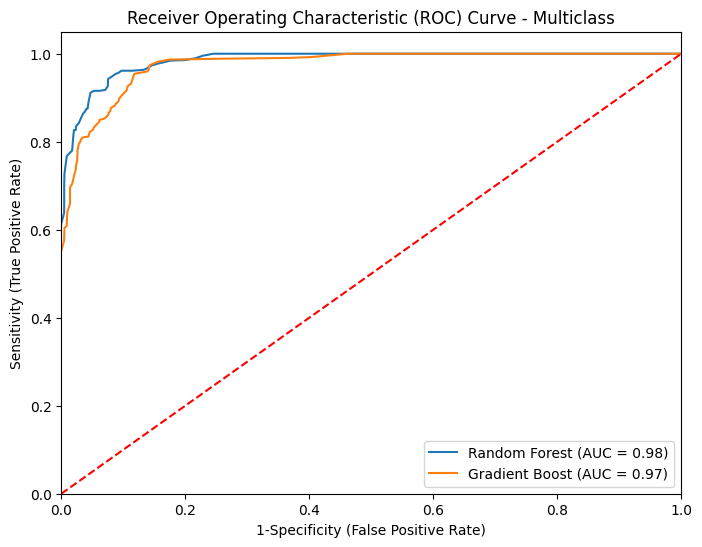

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import label_binarize

# Binarize the output labels for multiclass
n_classes = len(np.unique(y_train))  # Get number of unique classes
y_train_bin = label_binarize(y_train, classes=np.unique(y_train))
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

# Define models for comparison
auc_models = [
    {'label': 'Random Forest', 'model': RandomForestClassifier()},
    {'label': 'Gradient Boost', 'model': GradientBoostingClassifier()}
]

plt.figure(figsize=(8, 6))

# Iterate through models
for algo in auc_models:
    model = algo['model']
    model.fit(X_train, y_train)  # Train the model
    y_score = model.predict_proba(X_test)  # Get probability scores for each class

    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute **macro-average** ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes  # Average it

    # Compute AUC for the macro-average
    macro_roc_auc = auc(all_fpr, mean_tpr)

    # Plot the macro-average ROC curve
    plt.plot(all_fpr, mean_tpr, label=f'{algo["label"]} (AUC = {macro_roc_auc:.2f})')

# Plot the diagonal reference line
plt.plot([0, 1], [0, 1], 'r--')

# Custom settings for the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multiclass')
plt.legend(loc="lower right")

# Save and show plot
plt.savefig("multiclass_auc.png")
plt.show()


In [44]:
models = {
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)  # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred, average='weighted')
    model_train_recall = recall_score(y_train, y_train_pred, average='weighted')
    model_train_rocauc_score = roc_auc_score(y_train, model.predict_proba(X_train), multi_class='ovr')

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred, average='weighted')
    model_test_recall = recall_score(y_test, y_test_pred, average='weighted')
    model_test_rocauc_score = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')

    # Print results
    print(name)
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- ROC AUC Score: {:.4f}'.format(model_train_rocauc_score))

    print('----------------------------------')

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- ROC AUC Score: {:.4f}'.format(model_test_rocauc_score))

    print('=' * 35)
    print('\n')


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- ROC AUC Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8980
- F1 score: 0.8941
- Precision: 0.8971
- Recall: 0.8980
- ROC AUC Score: 0.9872




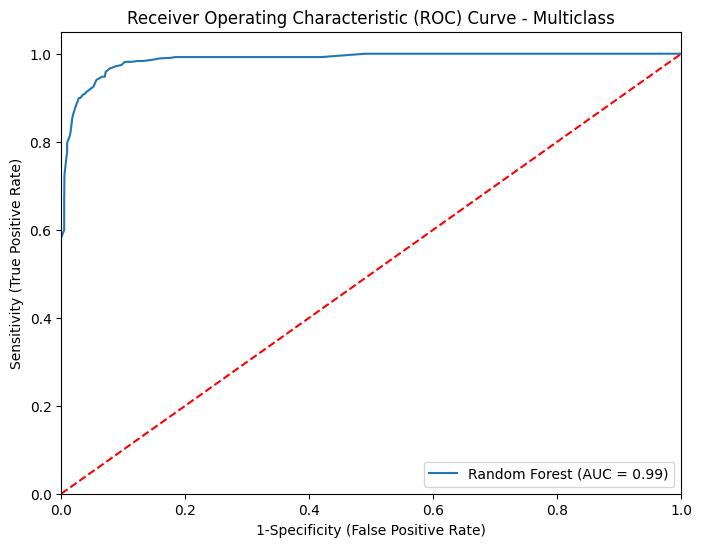

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize

# Binarize the output labels for multiclass
n_classes = len(np.unique(y_train))  # Get number of unique classes
y_train_bin = label_binarize(y_train, classes=np.unique(y_train))
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

# Define models for comparison
auc_models = [
    {'label': 'Random Forest', 'model': RandomForestClassifier()}]

plt.figure(figsize=(8, 6))

# Iterate through models
for algo in auc_models:
    model = algo['model']
    model.fit(X_train, y_train)  # Train the model
    y_score = model.predict_proba(X_test)  # Get probability scores for each class

    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute **macro-average** ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes  # Average it

    # Compute AUC for the macro-average
    macro_roc_auc = auc(all_fpr, mean_tpr)

    # Plot the macro-average ROC curve
    plt.plot(all_fpr, mean_tpr, label=f'{algo["label"]} (AUC = {macro_roc_auc:.2f})')

# Plot the diagonal reference line
plt.plot([0, 1], [0, 1], 'r--')

# Custom settings for the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multiclass')
plt.legend(loc="lower right")

# Save and show plot
plt.savefig("multiclass_auc.png")
plt.show()


## Checking the model Train Complete?

In [46]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

## Model Save To Device

In [47]:
import joblib  

# Save the trained model
joblib.dump(rf_model, "random_forest_model.pkl")  
print("Model saved successfully!")

Model saved successfully!


## Test The Model Using Real Time Data

In [48]:
import pandas as pd
import numpy as np
import joblib

# Load the saved model
rf_model = joblib.load("random_forest_model.pkl")

# Generate sample test data with more variability
np.random.seed(42)  # For reproducibility

# Sample values with a broader range and increased variability
sample_data = {
    'hive temp': np.random.uniform(15, 50, 10),  # Random temperature between 15 and 50
    'hive humidity': np.random.uniform(20, 90, 10),  # Random humidity between 20 and 90
    'hive pressure': np.random.uniform(980, 1050, 10),  # Random pressure between 980 and 1050
    'weather temp': np.random.uniform(-10, 45, 10),  # Random temperature between -10 and 45
    'weather humidity': np.random.uniform(10, 100, 10),  # Random humidity between 10 and 100
    'weather pressure': np.random.uniform(950, 1050, 10),  # Random pressure between 950 and 1050
    'RMS_Energy': np.random.uniform(0.03, 0.3, 10),  # Random RMS Energy with a wider range
    'Spectral_Centroid': np.random.uniform(520, 1450, 10),  # Random Spectral Centroid
    'Spectral_Contrast': np.random.uniform(15, 22, 10),  # Random Spectral Contrast
    'MFCC_1': np.random.uniform(-80, -280, 10),  # Random values for MFCC features
    'MFCC_2': np.random.uniform(110, 220, 10),
    'MFCC_3': np.random.uniform(-40, 40, 10),
    'MFCC_4': np.random.uniform(8, 70, 10),
    'MFCC_5': np.random.uniform(-35, 8, 10),
    'MFCC_6': np.random.uniform(-1, 31, 10),
    'MFCC_7': np.random.uniform(-16, 10, 10),
    'MFCC_8': np.random.uniform(0, 10, 10),
    'MFCC_9': np.random.uniform(-12, 2, 10),
    'MFCC_10': np.random.uniform(-11, 2.3, 10),
    'MFCC_11': np.random.uniform(-6, 12, 10),
    'MFCC_12': np.random.uniform(-13, -2.5, 10),
    'MFCC_13': np.random.uniform(-6, -7.5, 10),
}

# Create a DataFrame
new_data_df = pd.DataFrame(sample_data)

# Make predictions on new data using the loaded model
predictions = rf_model.predict(new_data_df)

print("Predictions:", predictions)


Predictions: [3 3 2 2 2 3 2 3 3 2]
